# 🧠 3-Class Brain MRI Classifier — ET / PD / Healthy
### Swin-B (torchvision) · FocalLoss + Class Weights · Minimal Augmentation · TTA · GradCAM · Attention Rollout · Brain Masking

| | |
|---|---|
| **Model** | `swin_b` — ImageNet-1K pretrained (88M params) |
| **Classes** | ET = 0 · PD = 1 · Healthy = 2 |
| **Loss** | FocalLoss (gamma=2, class weights [1.5, 1.5, 1.0]) — penalises hard ET/PD errors |
| **Sampling** | WeightedRandomSampler — over-samples ET & PD relative to Healthy |
| **Regularisation** | Dropout · no label smoothing · minimal spatial augmentation only |
| **Training** | 3-phase: head warm-up → partial unfreeze → full fine-tune |
| **Inference** | TTA (original + h-flip, majority soft-vote) |
| **Explainability** | GradCAM + Attention Rollout (fixed), both masked to brain tissue |


## 1 · Install Dependencies

In [1]:
%%capture
!pip install -q opencv-python-headless scipy scikit-learn

## 2 · Imports

In [2]:
import json, math, time, random, warnings
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.models import swin_b, Swin_B_Weights

from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}  "
      f"({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")

PyTorch : 2.10.0+cu128
CUDA    : True  (Tesla T4)


## 3 · Configuration

In [3]:
# ─── Data paths ────────────────────────────────────────────────────────────
PROCESSED_DIR  = Path("/kaggle/input/datasets/oovamoyo/preprocessed-dataset-3/processed")
MANIFEST_PATH  = PROCESSED_DIR / "manifest.csv"

# ─── Output ────────────────────────────────────────────────────────────────
BASE_DIR       = Path("/kaggle/working")
CHECKPOINT_DIR = BASE_DIR / "checkpoints_swin_b"
LOG_DIR        = BASE_DIR / "logs_swin_b"
for d in [CHECKPOINT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ─── Classes ───────────────────────────────────────────────────────────────
CLASS_NAMES  = ["ET", "PD", "Healthy"]
NUM_CLASSES  = 3
CLASS_TO_IDX = {"ET": 0, "PD": 1, "Healthy": 2}

# ─── Model ─────────────────────────────────────────────────────────────────
IMG_SIZE    = 224
EMBED_DIM   = 1024   # Swin-B final feature dim

# ─── Training ──────────────────────────────────────────────────────────────
BATCH_SIZE   = 16
NUM_WORKERS  = 2
PIN_MEMORY   = True

# Phase 1 — head only (backbone frozen)
PHASE1_EPOCHS      = 8
PHASE1_LR          = 3e-4
PHASE1_WD          = 1e-4

# Phase 2 — unfreeze last 2 Swin stages + norm
PHASE2_EPOCHS      = 10
PHASE2_LR_HEAD     = 5e-5
PHASE2_LR_PARTIAL  = 1e-5
PHASE2_WD          = 1e-4

# Phase 3 — full fine-tune with layer decay
# Head LR lowered (1e-4 → 3e-5) to avoid re-perturbing a converged Phase-2 solution
PHASE3_EPOCHS      = 15
PHASE3_LR_HEAD     = 3e-5
PHASE3_LR_BACKBONE = 3e-6
PHASE3_WD          = 1e-4

WARMUP_EPOCHS       = 2
GRAD_CLIP           = 1.0
EARLY_STOP_PATIENCE = 8

# ─── Loss ──────────────────────────────────────────────────────────────────
# Focal loss directs gradient toward hard ET/PD examples.
# Class weights [1.5, 1.5, 1.0] penalise ET & PD errors more than Healthy.
# Label smoothing removed — it softened the signal we need for hard classes.
FOCAL_GAMMA     = 2.0
CLASS_WEIGHTS   = [1.5, 1.5, 1.0]   # ET, PD, Healthy

# ─── Augmentation ──────────────────────────────────────────────────────────
# Minimal augmentation only — CutMix & MixUp removed because they destroyed
# the spatially-localised ET/PD features the model needs to learn.
H_FLIP_P     = 0.5
ROTATION_DEG = 5      # small rotation only; large angles distort brain anatomy

# ─── Explainability ────────────────────────────────────────────────────────
BRAIN_MASK_DILATE_PX = 8
BRAIN_MASK_SMOOTH_PX = 5
HEATMAP_ALPHA        = 0.45

# ─── Misc ──────────────────────────────────────────────────────────────────
SEED               = 42
MIN_SLICES_PATIENT = 3
TTA_MODES          = ["orig", "hflip"]   # v-flip removed (anatomically unsafe for brain MRI)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device  : {DEVICE}")
print(f"Classes : {CLASS_NAMES}")
print(f"Data    : {PROCESSED_DIR}")


Device  : cuda
Classes : ['ET', 'PD', 'Healthy']
Data    : /kaggle/input/datasets/oovamoyo/preprocessed-dataset-3/processed


## 4 · Reproducibility

In [4]:
def seed_everything(seed: int = SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

seed_everything()
print("Seed set.")

Seed set.


## 5 · Brain Masking *(for GradCAM / Rollout heatmaps)*

In [5]:
def _to_uint8(img: np.ndarray) -> np.ndarray:
    img = img.astype(np.float32)
    lo, hi = img.min(), img.max()
    if hi - lo < 1e-6:
        return np.zeros(img.shape[:2], dtype=np.uint8)
    return ((img - lo) / (hi - lo) * 255).astype(np.uint8)


def compute_brain_mask(
    image: np.ndarray,
    dilate_px: int = BRAIN_MASK_DILATE_PX,
    smooth_px: int = BRAIN_MASK_SMOOTH_PX,
    min_area_frac: float = 0.02,
) -> np.ndarray:
    gray  = cv2.cvtColor(image.astype(np.uint8), cv2.COLOR_RGB2GRAY) \
            if image.ndim == 3 else image.copy()
    gray8 = _to_uint8(gray)
    _, binary = cv2.threshold(gray8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = (binary > 0).astype(np.uint8)
    labeled, n = ndimage.label(binary)
    if n == 0:
        return np.zeros(gray8.shape, dtype=np.float32)
    sizes = ndimage.sum(binary, labeled, range(1, n + 1))
    min_a = min_area_frac * gray8.size
    keep  = [i+1 for i, s in enumerate(sizes) if s >= min_a] or [int(np.argmax(sizes))+1]
    mask  = np.isin(labeled, keep).astype(np.uint8)
    mask  = ndimage.binary_fill_holes(mask).astype(np.uint8)
    if dilate_px > 0:
        k    = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_px*2+1, dilate_px*2+1))
        mask = cv2.dilate(mask, k, iterations=1)
    soft = mask.astype(np.float32)
    if smooth_px > 0:
        soft = cv2.GaussianBlur(soft, (smooth_px*2+1, smooth_px*2+1), smooth_px)
    return np.clip(soft, 0.0, 1.0).astype(np.float32)


def apply_mask_to_heatmap(heatmap: np.ndarray, soft_mask: np.ndarray) -> np.ndarray:
    masked = heatmap * soft_mask
    hi = masked.max()
    return (masked / hi if hi > 1e-6 else masked).astype(np.float32)


def overlay_heatmap(
    image_rgb: np.ndarray, heatmap: np.ndarray, alpha: float = HEATMAP_ALPHA
) -> np.ndarray:
    h, w = image_rgb.shape[:2]
    hm = cv2.resize(heatmap, (w, h))
    hm = cv2.applyColorMap((np.clip(hm, 0, 1) * 255).astype(np.uint8), cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    out = (1 - alpha) * image_rgb.astype(np.float32) + alpha * hm.astype(np.float32)
    return np.clip(out, 0, 255).astype(np.uint8)


print("Brain mask helpers ready.")

Brain mask helpers ready.


## 6 · Dataset & WeightedRandomSampler


In [6]:
def build_transform(split: str) -> T.Compose:
    # Normalise to [−1, 1] (mean=0.5, std=0.5 per channel) — simpler than
    # ImageNet stats for grayscale-converted MRI, avoids channel mismatch.
    mean = [0.5, 0.5, 0.5]
    std  = [0.5, 0.5, 0.5]
    if split == "train":
        return T.Compose([
            T.Grayscale(num_output_channels=3),
            T.Resize((IMG_SIZE, IMG_SIZE)),
            T.RandomRotation(ROTATION_DEG),          # ±5° only
            T.RandomHorizontalFlip(p=H_FLIP_P),      # anatomically safe for brain MRI
            T.ToTensor(),
            T.Normalize(mean, std),
        ])
    return T.Compose([
        T.Grayscale(num_output_channels=3),
        T.Resize((IMG_SIZE, IMG_SIZE)),
        T.ToTensor(),
        T.Normalize(mean, std),
    ])


# TTA transforms — only orig + hflip (vflip removed: anatomically unsafe)
TTA_TRANSFORMS = {
    "orig":  T.Compose([T.Grayscale(num_output_channels=3), T.Resize((IMG_SIZE, IMG_SIZE)),
                         T.ToTensor(), T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])]),
    "hflip": T.Compose([T.Grayscale(num_output_channels=3), T.Resize((IMG_SIZE, IMG_SIZE)),
                         T.RandomHorizontalFlip(p=1.0),
                         T.ToTensor(), T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])]),
}


class FolderMRIDataset(Dataset):
    def __init__(self, split: str, transform: T.Compose,
                 processed_dir: Path = PROCESSED_DIR,
                 manifest_path: Path = MANIFEST_PATH,
                 tta_mode: Optional[str] = None):
        self.transform = transform
        self.tta_mode  = tta_mode
        self.records: List[Dict] = []

        pid_lookup: Dict[str, str] = {}
        if manifest_path.exists():
            mf = pd.read_csv(manifest_path)
            mf = mf[mf["split"] == split]
            for _, row in mf.iterrows():
                pid_lookup[str(row["abs_path"])] = str(row["patient_id"])

        for label in CLASS_NAMES:
            for fp in sorted((processed_dir / split / label).glob("*.png")):
                raw_pid = pid_lookup.get(str(fp), fp.stem)
                # Prefix with class name so patient IDs are unique per class.
                # Without this, shared IDs across folders corrupt patient-level eval.
                pid = f"{label}__{raw_pid}"
                self.records.append({
                    "path": str(fp), "label": CLASS_TO_IDX[label], "patient_id": pid,
                })

        counts = Counter(r["label"] for r in self.records)
        s = "  ".join(f"{CLASS_NAMES[i]}={counts[i]}" for i in range(NUM_CLASSES))
        print(f"  [{split:5s}]  total={len(self.records):6d}  |  {s}")

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        try:
            img = Image.open(rec["path"]).convert("L")
        except Exception as e:
            warnings.warn(f"Load error {rec['path']}: {e}")
            img = Image.fromarray(np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8))
        tfm = TTA_TRANSFORMS[self.tta_mode] if self.tta_mode else self.transform
        return {
            "image":      tfm(img),
            "label":      torch.tensor(rec["label"], dtype=torch.long),
            "patient_id": rec["patient_id"],
        }


def build_weighted_sampler(dataset: FolderMRIDataset):
    """WeightedRandomSampler: over-sample ET & PD so each class draws equally."""
    labels = [r["label"] for r in dataset.records]
    counts = Counter(labels)
    # Inverse-frequency weight per sample
    weight_per_class = {cls: 1.0 / cnt for cls, cnt in counts.items()}
    sample_weights   = torch.tensor([weight_per_class[l] for l in labels], dtype=torch.float)
    return torch.utils.data.WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )


def build_dataloaders():
    print("Loading dataset from:", PROCESSED_DIR)
    train_ds = FolderMRIDataset("train", build_transform("train"))
    val_ds   = FolderMRIDataset("val",   build_transform("val"))
    test_ds  = FolderMRIDataset("test",  build_transform("test"))

    sampler = build_weighted_sampler(train_ds)
    print(f"  WeightedRandomSampler active — {len(sampler):,} draws per epoch")

    # shuffle=False when using a sampler (sampler controls ordering)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_dataloaders()


Loading dataset from: /kaggle/input/datasets/oovamoyo/preprocessed-dataset-3/processed
  [train]  total= 11028  |  ET=3676  PD=3676  Healthy=3676
  [val  ]  total=  2331  |  ET=777  PD=777  Healthy=777
  [test ]  total=  2346  |  ET=782  PD=782  Healthy=782
  WeightedRandomSampler active — 11,028 draws per epoch


## 7 · Model — Swin-B with Residual Head

```
swin_b(weights=IMAGENET1K_V1)
  └── features   →  4 hierarchical Swin stages  (backbone)
  └── norm        →  LayerNorm(1024)             ← GradCAM hook target
  └── avgpool     →  AdaptiveAvgPool2d((1,1))
  └── head        →  replaced ↓

Custom 3-class head  (residual shortcut):
  LN(1024) → Linear(1024→512) → GELU → Dropout(0.4)
           → Linear(512→256)  → GELU → Dropout(0.3)
           → Linear(256→3)
  + shortcut  Linear(1024→3)  (added before final softmax)
```

In [7]:
class ResidualHead(nn.Module):
    """Deep head with a direct shortcut from input to logits."""
    def __init__(self, in_dim: int, num_classes: int):
        super().__init__()
        self.norm = nn.LayerNorm(in_dim)
        self.fc1  = nn.Linear(in_dim, 512)
        self.fc2  = nn.Linear(512, 256)
        self.fc3  = nn.Linear(256, num_classes)
        self.skip = nn.Linear(in_dim, num_classes)   # shortcut
        self.drop1 = nn.Dropout(0.4)
        self.drop2 = nn.Dropout(0.3)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode="fan_out")
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.norm(x)
        shortcut = self.skip(x)
        x = self.drop1(F.gelu(self.fc1(x)))
        x = self.drop2(F.gelu(self.fc2(x)))
        return self.fc3(x) + shortcut


class SwinBClassifier(nn.Module):
    def __init__(self, num_classes: int = NUM_CLASSES, pretrained: bool = True):
        super().__init__()
        weights = Swin_B_Weights.IMAGENET1K_V1 if pretrained else None
        base    = swin_b(weights=weights)
        print(f"Loaded torchvision swin_b  pretrained={pretrained}")

        self.features = base.features
        self.norm     = base.norm
        self.avgpool  = base.avgpool
        self.head     = ResidualHead(EMBED_DIM, num_classes)

        self._feat_store: Optional[torch.Tensor] = None
        self._grad_store: Optional[torch.Tensor] = None
        self._hooks: list = []

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)                       # (B, H', W', 1024)
        x = self.norm(x)                           # (B, H', W', 1024)
        x = self.avgpool(x.permute(0, 3, 1, 2))   # (B, 1024, 1, 1)
        x = torch.flatten(x, 1)                    # (B, 1024)
        return self.head(x)

    # ── GradCAM hooks ───────────────────────────────────────────────────────
    def register_gradcam_hooks(self):
        def fwd(m, inp, out):
            # Store activation WITHOUT detach so graph is intact; clone for safety
            self._feat_store = out.clone()
        def bwd(m, gi, go):
            # go[0] = gradient of loss w.r.t. norm output (B, H', W', C)
            self._grad_store = go[0].detach()
        self._hooks = [
            self.norm.register_forward_hook(fwd),
            self.norm.register_full_backward_hook(bwd),
        ]

    def remove_gradcam_hooks(self):
        for h in self._hooks: h.remove()
        self._hooks = []; self._feat_store = self._grad_store = None

    # ── Phase helpers ────────────────────────────────────────────────────────
    def freeze_backbone(self):
        for p in self.features.parameters(): p.requires_grad = False
        for p in self.norm.parameters():     p.requires_grad = False
        print("Backbone FROZEN — head only.")

    def partial_unfreeze(self):
        """Unfreeze last 2 Swin stages (features[4] and features[6]) + norm."""
        for p in self.features.parameters(): p.requires_grad = False
        for stage_idx in [4, 5, 6, 7]:
            for p in self.features[stage_idx].parameters():
                p.requires_grad = True
        for p in self.norm.parameters(): p.requires_grad = True
        print("Partial unfreeze: last 2 stages + norm.")

    def unfreeze_backbone(self):
        for p in self.features.parameters(): p.requires_grad = True
        for p in self.norm.parameters():     p.requires_grad = True
        print("Backbone UNFROZEN — full fine-tune.")

    def get_param_groups_partial(self) -> list:
        partial_bb = [p for n, p in self.named_parameters()
                      if p.requires_grad and "head" not in n and "skip" not in n]
        return [{"params": list(self.head.parameters()), "lr": PHASE2_LR_HEAD},
                {"params": partial_bb,                   "lr": PHASE2_LR_PARTIAL}]

    def get_param_groups_full(self) -> list:
        bb = list(self.features.parameters()) + list(self.norm.parameters())
        return [{"params": list(self.head.parameters()), "lr": PHASE3_LR_HEAD},
                {"params": bb,                           "lr": PHASE3_LR_BACKBONE}]

    def n_params(self, trainable=True) -> int:
        return sum(p.numel() for p in self.parameters()
                   if not trainable or p.requires_grad)

    def save(self, path: str):
        torch.save(self.state_dict(), path)
        print(f"Saved → {path}")

    @classmethod
    def load(cls, path: str, **kw):
        m = cls(**kw)
        m.load_state_dict(torch.load(path, map_location="cpu"))
        return m.eval()


model = SwinBClassifier().to(DEVICE)
print(f"Total params     : {model.n_params(trainable=False):,}")
print(f"Head params only : {sum(p.numel() for p in model.head.parameters()):,}")

Downloading: "https://download.pytorch.org/models/swin_b-68c6b09e.pth" to /root/.cache/torch/hub/checkpoints/swin_b-68c6b09e.pth


100%|██████████| 335M/335M [00:01<00:00, 212MB/s]


Loaded torchvision swin_b  pretrained=True
Total params     : 87,405,246
Head params only : 662,022


## 8 · Focal Loss with Class Weights


In [8]:
class FocalLoss(nn.Module):
    """
    Focal Loss — down-weights easy examples so the model focuses on hard ones.
    FL(p_t) = −α_t · (1 − p_t)^γ · log(p_t)
    gamma=2 is the standard choice; higher values focus more aggressively.
    class_weights acts as the α_t per-class balancing factor.
    """
    def __init__(self, gamma: float = 2.0, weight: Optional[torch.Tensor] = None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight  # per-class balancing weights (α)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Standard CE loss (per-sample, no reduction) with class weights
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        # p_t = exp(−CE) is the model probability assigned to the true class
        p_t     = torch.exp(-ce_loss)
        focal   = (1.0 - p_t) ** self.gamma * ce_loss
        return focal.mean()


class_weights = torch.tensor(CLASS_WEIGHTS, dtype=torch.float).to(DEVICE)
criterion     = FocalLoss(gamma=FOCAL_GAMMA, weight=class_weights).to(DEVICE)
print(f"FocalLoss ready.  gamma={FOCAL_GAMMA}  class_weights={CLASS_WEIGHTS}")


FocalLoss ready.  gamma=2.0  class_weights=[1.5, 1.5, 1.0]


## 9 · Explainability — GradCAM + Attention Rollout (Fixed)

**Bug fixes vs original:**
1. Forward hook stores `out.clone()` (not `out.detach()`) so the computation graph is intact for backward.
2. `AttentionRollout` uses `(H, W)` spatial dims directly — no broken `isqrt` reshape.
3. `explain()` computes rollout only when needed (method ≠ "gradcam").


In [9]:
# ── GradCAM ─────────────────────────────────────────────────────────────────
def gradcam(
    model_: SwinBClassifier,
    tensor: torch.Tensor,
    class_idx: Optional[int] = None,
    orig_np: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, int]:
    if tensor.dim() == 3:
        tensor = tensor.unsqueeze(0)
    tensor = tensor.to(DEVICE)
    model_.eval()
    model_.register_gradcam_hooks()

    tensor = tensor.requires_grad_(True)
    logits   = model_(tensor)
    pred_cls = logits.argmax(1).item()
    target   = class_idx if class_idx is not None else pred_cls

    model_.zero_grad()
    logits[0, target].backward()

    feats = model_._feat_store   # (B, H', W', C)
    grads = model_._grad_store   # (B, H', W', C)
    model_.remove_gradcam_hooks()

    if feats is None or grads is None:
        return np.zeros((IMG_SIZE, IMG_SIZE), np.float32), pred_cls

    feats = feats.detach().squeeze(0)   # (H', W', C)
    grads = grads.squeeze(0)            # (H', W', C)
    alpha = grads.mean(dim=(0, 1))      # (C,)
    cam   = torch.clamp((alpha * feats).sum(dim=-1), min=0).cpu().numpy()  # (H', W')
    cam   = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    hi    = cam.max()
    cam   = cam / hi if hi > 1e-6 else cam

    ref = orig_np if orig_np is not None else (
        (tensor.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()
         * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
         ) * 255).clip(0, 255).astype(np.uint8)
    return apply_mask_to_heatmap(cam, compute_brain_mask(ref)).astype(np.float32), pred_cls


# ── Attention Rollout (Fixed) ────────────────────────────────────────────────
class AttentionRollout:
    """
    Aggregates feature activation magnitude across all SwinTransformerBlocks.
    FIX: Uses (H, W) spatial dims directly — no broken isqrt reshape.
    """
    def __init__(self, model_: SwinBClassifier):
        self.model_ = model_
        self._maps: list = []
        self._hooks: list = []
        self._register()

    def _register(self):
        from torchvision.models.swin_transformer import SwinTransformerBlock
        def hook(m, inp, out):
            # out: (B, H, W, C) for torchvision Swin
            self._maps.append(out.detach().cpu())
        for m in self.model_.features.modules():
            if isinstance(m, SwinTransformerBlock):
                self._hooks.append(m.register_forward_hook(hook))

    def __call__(
        self, tensor: torch.Tensor, orig_np: Optional[np.ndarray] = None
    ) -> np.ndarray:
        if tensor.dim() == 3:
            tensor = tensor.unsqueeze(0)
        tensor = tensor.to(DEVICE)
        self._maps.clear()
        self.model_.eval()
        with torch.no_grad():
            self.model_(tensor)
        if not self._maps:
            return np.zeros((IMG_SIZE, IMG_SIZE), np.float32)

        aggregated = None
        for block_out in self._maps:
            # block_out: (B, H, W, C)  — use (H, W) directly, no reshaping
            mag = block_out.abs().mean(dim=-1).squeeze(0).numpy()  # (H, W)
            lo, hi = mag.min(), mag.max()
            mag = (mag - lo) / (hi - lo + 1e-8)
            if aggregated is None:
                aggregated = cv2.resize(mag.astype(np.float32), (IMG_SIZE, IMG_SIZE))
            else:
                mag_r = cv2.resize(mag.astype(np.float32), (IMG_SIZE, IMG_SIZE))
                aggregated = aggregated + mag_r   # additive rollout approximation

        lo, hi = aggregated.min(), aggregated.max()
        rollout = ((aggregated - lo) / (hi - lo + 1e-8)).astype(np.float32)

        ref = orig_np if orig_np is not None else (
            (tensor.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()
             * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
             ) * 255).clip(0, 255).astype(np.uint8)
        return apply_mask_to_heatmap(rollout, compute_brain_mask(ref)).astype(np.float32)

    def close(self):
        for h in self._hooks: h.remove()
        self._hooks = []; self._maps.clear()


class MRIExplainer:
    def __init__(self, model_: SwinBClassifier):
        self.model_  = model_
        self.rollout = AttentionRollout(model_)

    def explain(
        self, tensor, class_idx=None, orig_np=None, method="combined"
    ) -> Tuple[np.ndarray, int, np.ndarray]:
        cam_map, pred = gradcam(self.model_, tensor, class_idx, orig_np)
        # Only compute rollout when needed
        if method in ("rollout", "combined"):
            rol_map = self.rollout(tensor, orig_np)
        if   method == "gradcam":  hm = cam_map
        elif method == "rollout":  hm = rol_map
        else:
            hm = 0.6 * cam_map + 0.4 * rol_map
            hi = hm.max(); hm = hm / hi if hi > 1e-6 else hm
        ref  = orig_np if orig_np is not None else (
            (tensor.detach().cpu().squeeze(0).permute(1, 2, 0).numpy()
             * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
             ) * 255).clip(0, 255).astype(np.uint8)
        base = cv2.resize(ref, (IMG_SIZE, IMG_SIZE)) if ref.shape[:2] != (IMG_SIZE, IMG_SIZE) else ref
        return hm, pred, overlay_heatmap(base, hm)

    def close(self): self.rollout.close()


print("Explainability classes ready (bugs fixed).")

Explainability classes ready (bugs fixed).


## 10 · Training Loop


In [10]:
# CutMix and MixUp removed — they destroyed spatially-localised ET/PD features.
# run_epoch now uses clean labels throughout; training AUC is now computable.

def run_epoch(model_, loader, crit, opt, scaler, train_):
    model_.train() if train_ else model_.eval()
    total_loss = 0.0
    all_labels, all_preds, all_probs = [], [], []

    ctx = torch.enable_grad() if train_ else torch.no_grad()
    with ctx:
        for batch in loader:
            imgs   = batch["image"].to(DEVICE, non_blocking=True)
            labels = batch["label"].to(DEVICE, non_blocking=True)

            with torch.amp.autocast("cuda", enabled=(scaler is not None)):
                logits = model_(imgs)
                loss   = crit(logits, labels)

            if train_:
                opt.zero_grad()
                if scaler:
                    scaler.scale(loss).backward()
                    scaler.unscale_(opt)
                    nn.utils.clip_grad_norm_(model_.parameters(), GRAD_CLIP)
                    scaler.step(opt); scaler.update()
                else:
                    loss.backward()
                    nn.utils.clip_grad_norm_(model_.parameters(), GRAD_CLIP)
                    opt.step()

            total_loss += loss.item() * len(labels)
            probs = torch.softmax(logits.detach(), dim=-1).cpu().numpy()
            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(probs.argmax(1).tolist())
            all_probs.append(probs)

    all_probs = np.vstack(all_probs)
    acc = accuracy_score(all_labels, all_preds)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    except ValueError:
        auc = float("nan")
    return total_loss / max(len(all_labels), 1), acc, auc, all_labels, all_preds, all_probs


print("Training loop ready (no CutMix/MixUp — clean labels throughout).")


Training loop ready (no CutMix/MixUp — clean labels throughout).


## 11 · Run Training (3-phase)

| Phase | Epochs | Backbone | Strategy |
|---|---|---|---|
| 1 | 8 | Frozen | Head warm-up only |
| 2 | 10 | Last 2 stages + norm | Partial unfreeze |
| 3 | 15 | All layers | Full fine-tune with layer-decay LRs |

In [11]:
scaler    = torch.amp.GradScaler("cuda") if DEVICE.type == "cuda" else None
history   = []
best_auc  = -1.0
best_ckpt = str(CHECKPOINT_DIR / "best_swin_b.pt")

# ══════════════════════════════════════════════════════════════════
# PHASE 1  —  frozen backbone, head only
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("PHASE 1  —  Frozen backbone  (head only)")
print("═"*60)
model.freeze_backbone()
print(f"Trainable params: {model.n_params():,}")

opt1   = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
               lr=PHASE1_LR, weight_decay=PHASE1_WD)
sched1 = CosineAnnealingLR(opt1, T_max=PHASE1_EPOCHS)

for ep in range(1, PHASE1_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, tr_auc, *_ = run_epoch(model, train_loader, criterion, opt1, scaler, True)
    va_loss, va_acc, va_auc, *_ = run_epoch(model, val_loader,   criterion, None, None,  False)
    sched1.step()
    history.append({"phase":1,"ep":ep,"tr_loss":tr_loss,"va_loss":va_loss,
                    "tr_acc":tr_acc,"va_acc":va_acc,"tr_auc":tr_auc,"va_auc":va_auc})
    tag = ""
    if va_auc > best_auc:
        best_auc = va_auc; model.save(best_ckpt); tag = " ✔"
    print(f"  P1 E{ep:02d}  tr={tr_loss:.4f}/{tr_acc:.3f}/{tr_auc:.3f}  │"
          f"  va={va_loss:.4f}/{va_acc:.3f}/{va_auc:.3f}  ({time.time()-t0:.1f}s){tag}")

# ══════════════════════════════════════════════════════════════════
# PHASE 2  —  partial unfreeze (last 2 stages)
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("PHASE 2  —  Partial unfreeze  (last 2 Swin stages)")
print("═"*60)
model.partial_unfreeze()
print(f"Trainable params: {model.n_params():,}")

opt2   = AdamW(model.get_param_groups_partial(), weight_decay=PHASE2_WD)
warmup2 = LinearLR(opt2, start_factor=0.1, total_iters=2)
cosine2 = CosineAnnealingLR(opt2, T_max=PHASE2_EPOCHS - 2)
sched2  = SequentialLR(opt2, schedulers=[warmup2, cosine2], milestones=[2])

patience = 0
for ep in range(1, PHASE2_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, tr_auc, *_ = run_epoch(model, train_loader, criterion, opt2, scaler, True)
    va_loss, va_acc, va_auc, *_ = run_epoch(model, val_loader,   criterion, None, None,  False)
    sched2.step()
    history.append({"phase":2,"ep":ep,"tr_loss":tr_loss,"va_loss":va_loss,
                    "tr_acc":tr_acc,"va_acc":va_acc,"tr_auc":tr_auc,"va_auc":va_auc})
    if va_auc > best_auc:
        best_auc = va_auc; model.save(best_ckpt); patience = 0; tag = " ✔ NEW BEST"
    else:
        patience += 1; tag = ""
    print(f"  P2 E{ep:02d}  tr={tr_loss:.4f}/{tr_acc:.3f}/{tr_auc:.3f}  │"
          f"  va={va_loss:.4f}/{va_acc:.3f}/{va_auc:.3f}  ({time.time()-t0:.1f}s){tag}")
    if patience >= EARLY_STOP_PATIENCE:
        print(f"  Early stop P2."); break

# ══════════════════════════════════════════════════════════════════
# PHASE 3  —  full fine-tune
# ══════════════════════════════════════════════════════════════════
print("\n" + "═"*60)
print("PHASE 3  —  Full fine-tune  (discriminative LRs)")
print("═"*60)
model.unfreeze_backbone()
print(f"Trainable params: {model.n_params():,}")

opt3   = AdamW(model.get_param_groups_full(), weight_decay=PHASE3_WD)
warmup3 = LinearLR(opt3, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine3 = CosineAnnealingLR(opt3, T_max=PHASE3_EPOCHS - WARMUP_EPOCHS)
sched3  = SequentialLR(opt3, schedulers=[warmup3, cosine3], milestones=[WARMUP_EPOCHS])

patience = 0
for ep in range(1, PHASE3_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc, tr_auc, *_ = run_epoch(model, train_loader, criterion, opt3, scaler, True)
    va_loss, va_acc, va_auc, *_ = run_epoch(model, val_loader,   criterion, None, None,  False)
    sched3.step()
    history.append({"phase":3,"ep":ep,"tr_loss":tr_loss,"va_loss":va_loss,
                    "tr_acc":tr_acc,"va_acc":va_acc,"tr_auc":tr_auc,"va_auc":va_auc})
    if va_auc > best_auc:
        best_auc = va_auc; model.save(best_ckpt); patience = 0; tag = " ✔ NEW BEST"
    else:
        patience += 1; tag = ""
    print(f"  P3 E{ep:02d}  tr={tr_loss:.4f}/{tr_acc:.3f}/{tr_auc:.3f}  │"
          f"  va={va_loss:.4f}/{va_acc:.3f}/{va_auc:.3f}  ({time.time()-t0:.1f}s){tag}")
    if patience >= EARLY_STOP_PATIENCE:
        print(f"  Early stop P3."); break

print(f"\nBest val AUC = {best_auc:.4f}")


════════════════════════════════════════════════════════════
PHASE 1  —  Frozen backbone  (head only)
════════════════════════════════════════════════════════════
Backbone FROZEN — head only.
Trainable params: 662,022
Saved → /kaggle/working/checkpoints_swin_b/best_swin_b.pt
  P1 E01  tr=15.0849/0.578/nan  │  va=5.0427/0.748/0.894  (89.0s) ✔
Saved → /kaggle/working/checkpoints_swin_b/best_swin_b.pt
  P1 E02  tr=7.8600/0.676/nan  │  va=3.9286/0.751/0.904  (101.9s) ✔
Saved → /kaggle/working/checkpoints_swin_b/best_swin_b.pt
  P1 E03  tr=6.3860/0.704/nan  │  va=3.0437/0.782/0.918  (102.0s) ✔
Saved → /kaggle/working/checkpoints_swin_b/best_swin_b.pt
  P1 E04  tr=5.5282/0.717/0.851  │  va=2.5842/0.813/0.927  (103.7s) ✔
Saved → /kaggle/working/checkpoints_swin_b/best_swin_b.pt
  P1 E05  tr=4.7459/0.732/nan  │  va=2.1103/0.815/0.935  (102.3s) ✔
Saved → /kaggle/working/checkpoints_swin_b/best_swin_b.pt
  P1 E06  tr=4.2720/0.747/nan  │  va=2.0724/0.817/0.939  (101.4s) ✔
Saved → /kaggle/working

## 12 · Learning Curves

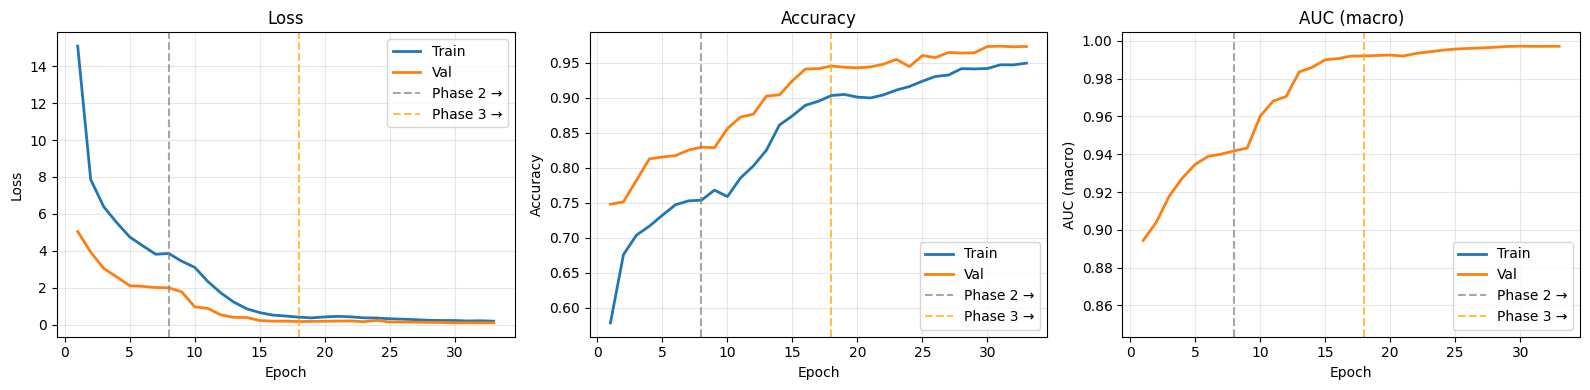

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
epochs = list(range(1, len(history)+1))
p1_end = sum(1 for h in history if h["phase"] == 1)
p2_end = sum(1 for h in history if h["phase"] <= 2)

for ax, (tk, vk), ylabel in zip(
    axes,
    [("tr_loss","va_loss"),("tr_acc","va_acc"),("tr_auc","va_auc")],
    ["Loss", "Accuracy", "AUC (macro)"],
):
    ax.plot(epochs, [h[tk] for h in history], label="Train", lw=2)
    ax.plot(epochs, [h[vk] for h in history], label="Val",   lw=2)
    ax.axvline(p1_end, color="grey",  ls="--", alpha=0.7, label="Phase 2 →")
    ax.axvline(p2_end, color="orange",ls="--", alpha=0.7, label="Phase 3 →")
    ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel); ax.set_title(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(LOG_DIR / "swin_b_learning_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## 13 · Test Evaluation with TTA

Loading best checkpoint…
Test Accuracy (TTA) : 0.9574
Test AUC    (TTA)   : 0.9950

              precision    recall  f1-score   support

          ET     0.9361    0.9373    0.9367       782
          PD     0.9384    0.9348    0.9366       782
     Healthy     0.9974    1.0000    0.9987       782

    accuracy                         0.9574      2346
   macro avg     0.9573    0.9574    0.9573      2346
weighted avg     0.9573    0.9574    0.9573      2346



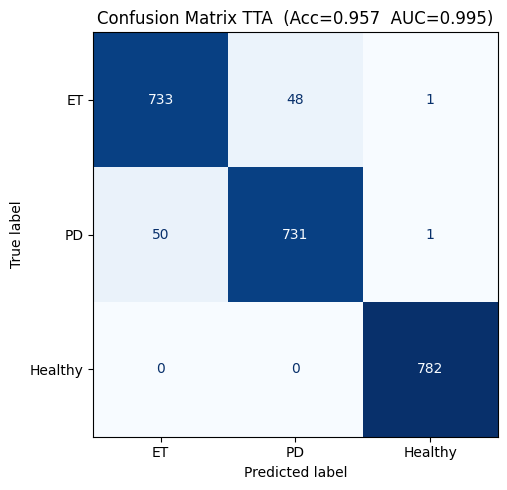

In [13]:
print("Loading best checkpoint…")
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE))
model.eval()


def tta_predict(model_, ds, batch_size=BATCH_SIZE):
    """
    Test-Time Augmentation: average softmax probs across TTA_MODES.
    Returns (all_labels, all_preds, all_probs_avg).
    """
    all_probs_list = []
    all_labels = None

    for mode in TTA_MODES:
        ds.tta_mode = mode
        loader = DataLoader(ds, batch_size=batch_size, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
        mode_probs, mode_labels = [], []
        with torch.no_grad():
            for batch in loader:
                imgs = batch["image"].to(DEVICE)
                prob = torch.softmax(model_(imgs), dim=-1).cpu().numpy()
                mode_probs.append(prob)
                mode_labels.extend(batch["label"].numpy().tolist())
        all_probs_list.append(np.vstack(mode_probs))
        if all_labels is None:
            all_labels = mode_labels

    ds.tta_mode = None  # reset
    avg_probs = np.mean(all_probs_list, axis=0)
    all_preds = avg_probs.argmax(1).tolist()
    return all_labels, all_preds, avg_probs


# Slice-level
tl, tp, tp_prob = tta_predict(model, test_loader.dataset)
test_acc = accuracy_score(tl, tp)
test_auc = roc_auc_score(tl, tp_prob, multi_class="ovr", average="macro")
print(f"Test Accuracy (TTA) : {test_acc:.4f}")
print(f"Test AUC    (TTA)   : {test_auc:.4f}\n")
print(classification_report(tl, tp, target_names=CLASS_NAMES, digits=4))

cm   = confusion_matrix(tl, tp)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix TTA  (Acc={test_acc:.3f}  AUC={test_auc:.3f})")
plt.tight_layout()
plt.savefig(str(LOG_DIR / "swin_b_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

## 15 · Visualise GradCAM + Attention Rollout

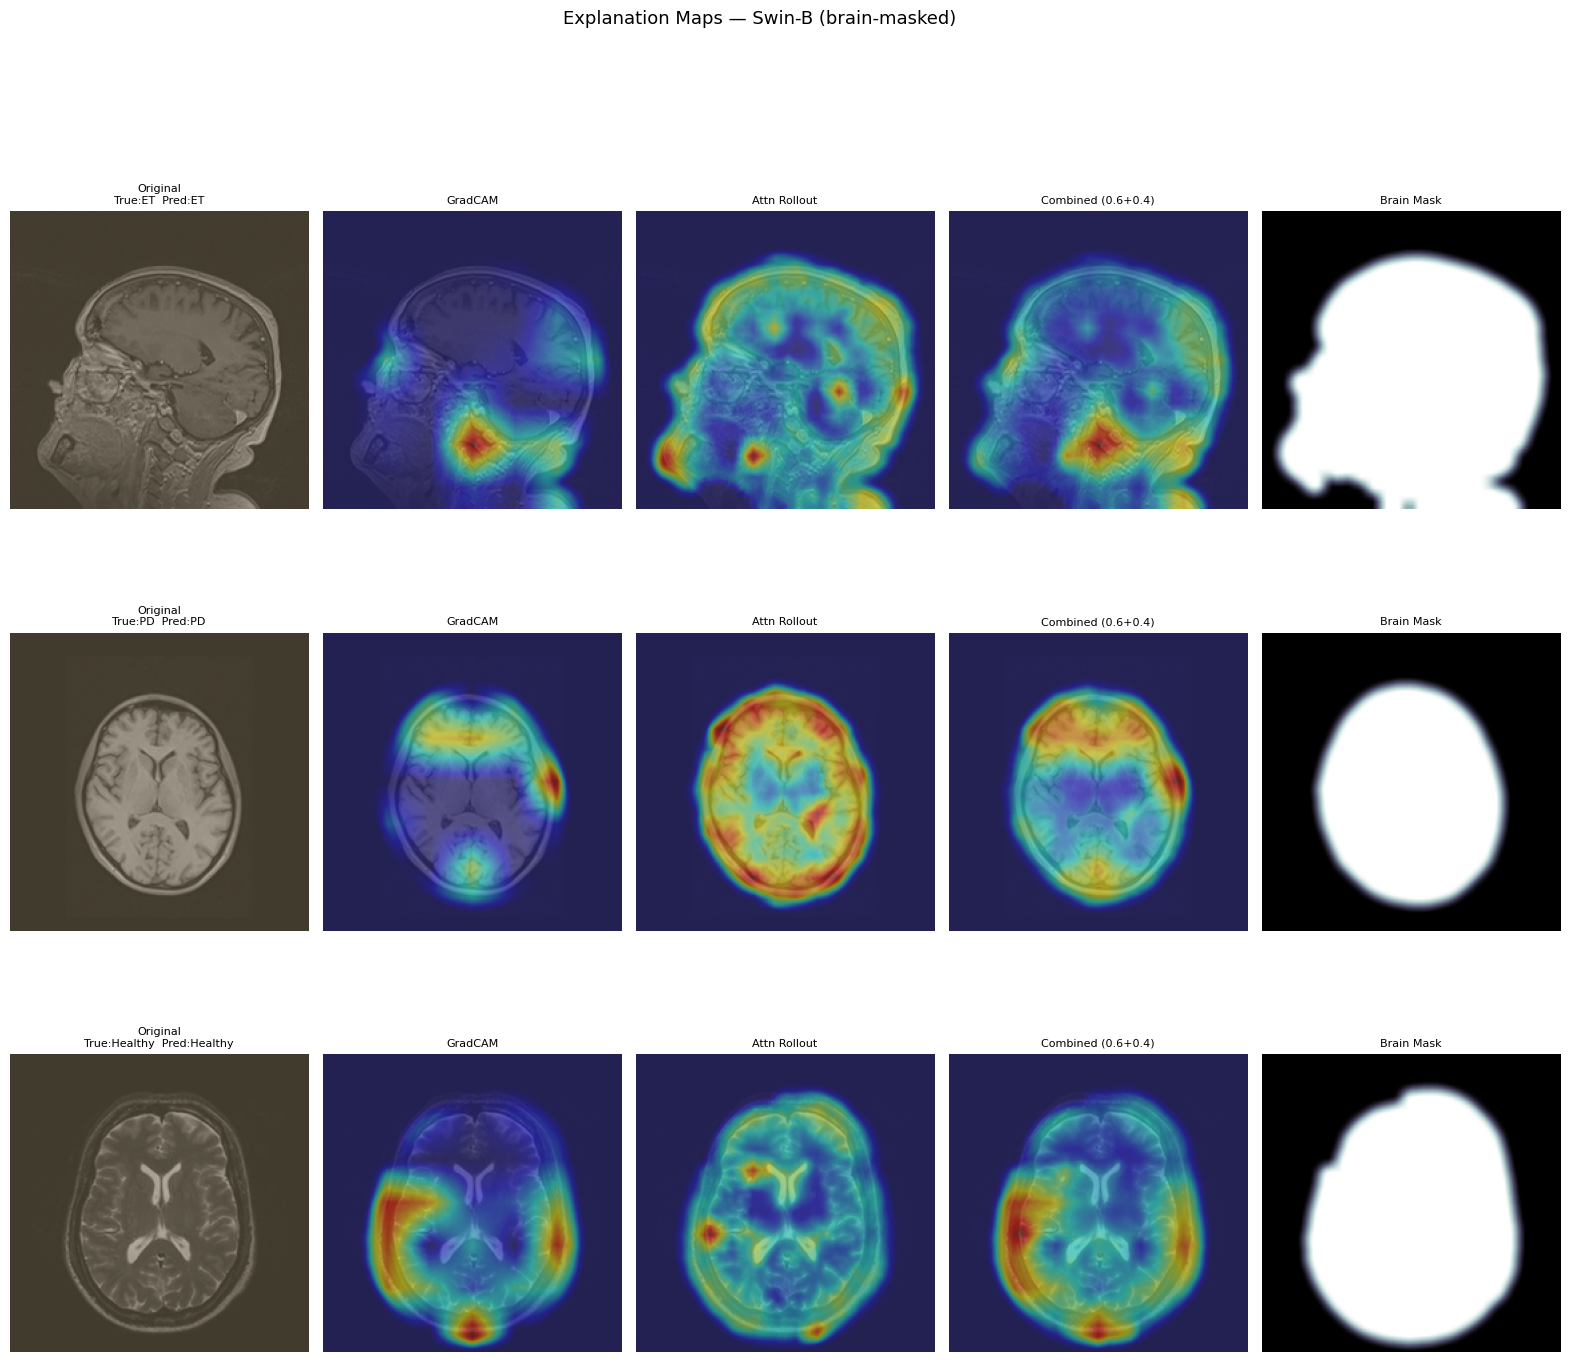

In [14]:
explainer = MRIExplainer(model)

def denorm(t: torch.Tensor) -> np.ndarray:
    arr = t.squeeze(0).permute(1, 2, 0).numpy()
    return ((arr * np.array([0.229, 0.224, 0.225])
             + np.array([0.485, 0.456, 0.406])) * 255
            ).clip(0, 255).astype(np.uint8)

# One sample per class from the test set
samples = {cn: None for cn in CLASS_NAMES}
for batch in test_loader:
    for i in range(len(batch["label"])):
        cn = CLASS_NAMES[int(batch["label"][i])]
        if samples[cn] is None:
            samples[cn] = (batch["image"][i], batch["label"][i])
    if all(v is not None for v in samples.values()):
        break

fig = plt.figure(figsize=(20, 5 * NUM_CLASSES))
gs  = gridspec.GridSpec(NUM_CLASSES, 5, figure=fig, hspace=0.35, wspace=0.05)

for row, cn in enumerate(CLASS_NAMES):
    if samples[cn] is None: continue
    tensor, _ = samples[cn]
    orig_np   = denorm(tensor)
    orig_r    = cv2.resize(orig_np, (IMG_SIZE, IMG_SIZE))

    _, pred, ov_cam     = explainer.explain(tensor, orig_np=orig_r, method="gradcam")
    _, _,    ov_rol     = explainer.explain(tensor, orig_np=orig_r, method="rollout")
    _, _,    ov_comb    = explainer.explain(tensor, orig_np=orig_r, method="combined")

    soft_mask = compute_brain_mask(orig_r)
    mask_disp = cv2.cvtColor(
        cv2.applyColorMap((soft_mask * 255).astype(np.uint8), cv2.COLORMAP_BONE),
        cv2.COLOR_BGR2RGB
    )

    for col, (title, img) in enumerate(zip(
        [f"Original\nTrue:{cn}  Pred:{CLASS_NAMES[pred]}",
         "GradCAM", "Attn Rollout", "Combined (0.6+0.4)", "Brain Mask"],
        [orig_r, ov_cam, ov_rol, ov_comb, mask_disp]
    )):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(img); ax.set_title(title, fontsize=8); ax.axis("off")

plt.suptitle("Explanation Maps — Swin-B (brain-masked)", fontsize=13, y=1.01)
plt.savefig(str(LOG_DIR / "swin_b_explanations.png"), dpi=150, bbox_inches="tight")
plt.show()
explainer.close()

## 16 · Save Artefacts

In [15]:
with open(str(LOG_DIR / "swin_b_history.json"), "w") as f:
    json.dump(history, f, indent=2)
model.save(str(CHECKPOINT_DIR / "swin_b_final.pt"))

print("Saved:")
for p in [
    CHECKPOINT_DIR / "best_swin_b.pt",
    CHECKPOINT_DIR / "swin_b_final.pt",
    LOG_DIR / "swin_b_history.json",
    LOG_DIR / "swin_b_learning_curves.png",
    LOG_DIR / "swin_b_confusion_matrix.png",
    LOG_DIR / "swin_b_explanations.png",
]:
    print(f"  {p}")

Saved → /kaggle/working/checkpoints_swin_b/swin_b_final.pt
Saved:
  /kaggle/working/checkpoints_swin_b/best_swin_b.pt
  /kaggle/working/checkpoints_swin_b/swin_b_final.pt
  /kaggle/working/logs_swin_b/swin_b_history.json
  /kaggle/working/logs_swin_b/swin_b_learning_curves.png
  /kaggle/working/logs_swin_b/swin_b_confusion_matrix.png
  /kaggle/working/logs_swin_b/swin_b_explanations.png
